# Final Model Comparisons: ST-GNN vs ConvLSTM vs LSTM

This notebook compares the final **ST-GNN**, **ConvLSTM**, and **LSTM** (Ex5) SWE predictions on a common set of HUC12s. It loads time-split ST-GNN results and precomputed ConvLSTM/LSTM metrics, filters to the same HUC IDs, computes per-HUC KGE and MSE for ST-GNN (using UA as reference), and produces box plots of Test KGE by model.

## Imports

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import boto3
from io import StringIO
from io import BytesIO
from sklearn.metrics import mean_squared_error

In [13]:
s3 = boto3.client('s3')
bucket = "spatiotemporal-results"

## Load data

Load ST-GNN time-split test results, ConvLSTM results, and LSTM (Ex5) metrics (Montane + Maritime). LSTM HUC IDs define the common evaluation set.

In [14]:
convlstm_key = "convlstm/convlstm_results.csv"
convlstm_obj = s3.get_object(Bucket=bucket, Key=convlstm_key)
stgnn_key = "stgnn/temporal_split/st_gnn_time_split_test_results_all_runs.csv.gz"
stgnn_obj = s3.get_object(Bucket=bucket, Key=stgnn_key)

In [15]:
df_stgnn = pd.read_csv(BytesIO(stgnn_obj["Body"].read()), compression="gzip")
df_convlstm = pd.read_csv(StringIO(convlstm_obj['Body'].read().decode('utf-8')))
montane_df  = pd.read_csv("../../../../notebooks/Ex5_DataIntegration/single_all_metrics_w_snow_types_and_elev_Montane.csv")
maritime_df  = pd.read_csv("../../../../notebooks/Ex5_DataIntegration/single_all_metrics_w_snow_types_and_elev_Maritime_DI_mse.csv")
# ephemeral_df  = pd.read_csv("../../../../notebooks/Ex5_DataIntegration/single_all_metrics_w_snow_types_and_elev_Ephemeral_DI_mse.csv")
df_lstm = pd.concat([montane_df, maritime_df], ignore_index=True)

Preview the first two rows of each loaded DataFrame to confirm structure and column names.

In [16]:
print(df_stgnn.head(2))
print(df_convlstm.head(2))
print(df_lstm.head(2))


         huc_id         day  pred_run_1  pred_run_2  pred_run_3  pred_run_4  \
0  170200090101  2009-11-18    0.163723    0.169625    0.172638    0.164396   
1  170200090101  2009-11-19    0.175724    0.177216    0.184886    0.170885   

   pred_run_5  pred_mean  pred_std  ua_swe  era5_swe  snodas_swe  \
0    0.165876   0.167252  0.003381  0.1875  0.225069    0.146380   
1    0.179418   0.177626  0.004586  0.1990  0.239911    0.149602   

  Predominant Snow  Mean Elevation  
0         Maritime     1758.266724  
1         Maritime     1758.266724  
       huc12_id          mse    rmse_mm       kge        snowtype   huc8_id
0  170103020101  3229.549654  56.829127  0.856647  Montane Forest  17010302
1  170103020102  2798.650342  52.902272  0.841030  Montane Forest  17010302
         HUC_ID                                               Name  Test MSE  \
0  170103020101  Little North Fork South Fork Coeur d'Alene Riv...  0.020238   
1  170103020102  Canyon Creek-Upper South Fork Coeur d'Ale

Get the list of HUC IDs from the LSTM results; this set defines the common HUCs for fair comparison across all three models.

In [4]:
final_huc_ids = df_lstm['HUC_ID']
len(final_huc_ids)

341

Filter ST-GNN and ConvLSTM to only HUCs that appear in the LSTM evaluation set so all models are compared on the same HUCs.

In [16]:
df_stgnn = df_stgnn[df_stgnn['huc_id'].isin(final_huc_ids)]
df_convlstmn = df_convlstm[df_convlstm['huc12_id'].isin(final_huc_ids)]

## Metrics: KGE and MSE

Define **Kling–Gupta efficiency (KGE)** and **compute_metrics**: both return KGE and MSE for a pair of (y_true, y_pred) arrays, used to evaluate ST-GNN per HUC against UA SWE.

In [17]:
def kling_gupta_efficiency(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    # NaN check
    if np.isnan(y_true).any() or np.isnan(y_pred).any():
        return np.nan, np.nan, np.nan, np.nan

    # Zero variance check
    if np.std(y_true) == 0 or np.std(y_pred) == 0:
        return np.nan, np.nan, np.nan, np.nan

    r = np.corrcoef(y_true, y_pred)[0, 1]
    alpha = np.std(y_pred) / (np.std(y_true) + eps)

    mean_true = np.mean(y_true)
    if np.isclose(mean_true, 0.0):
        beta = np.nan
    else:
        beta = np.mean(y_pred) / (mean_true + eps)

    kge = 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)
    return kge



def compute_metrics(y_true, y_pred):
    """Calculate all evaluation metrics (KGE, MSE, etc.)."""
    if np.isnan(y_true).any() or np.isnan(y_pred).any():
        return {'mse': np.nan, 'kge': np.nan}
    kge = kling_gupta_efficiency(y_true, y_pred)
    return {
        'mse': mean_squared_error(y_true, y_pred),
        'kge': kge
    }

Compute per-HUC KGE and MSE for ST-GNN by grouping on `huc_id` and applying `compute_metrics(ua_swe, pred_mean)`. Produces one row per HUC for box plots.

In [18]:
# Compute KGE (and MSE) per huc_id using compute_metrics(UA_swe, pred_mean), then one row per huc_id for box plots
def metrics_per_huc(g):
    m = compute_metrics(g["ua_swe"].values, g["pred_mean"].values)
    return pd.Series({"kge": m["kge"], "mse": m["mse"]})

stgnn_metrics = df_stgnn.groupby("huc_id").apply(metrics_per_huc).reset_index()
stgnn_metrics.head(2)


/tmp/ipykernel_594128/3386902268.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stgnn_metrics = df_stgnn.groupby("huc_id").apply(metrics_per_huc).reset_index()


,huc_id,kge,mse
0,170103020101,0.991740,0.000335
1,170103020102,0.974298,0.000250


Rename columns so ST-GNN and ConvLSTM DataFrames use the same names (`HUC_ID`, `Test KGE`) as LSTM for combined plotting.

In [ ]:
df_stgnn_final = stgnn_metrics.rename(columns={
    'kge': 'Test KGE',
    'huc_id': 'HUC_ID'
})
df_convlstm_final = df_convlstm.rename(columns={
    'kge': 'Test KGE',
    'huc12_id': 'HUC_ID'
})

Preview the aligned ConvLSTM, ST-GNN, and LSTM DataFrames after renaming.

In [ ]:
print(df_convlstm_final.head(2))
print(df_stgnn_final.head(2))
print(df_lstm.head(2))

         HUC_ID          mse    rmse_mm  Test KGE        snowtype   huc8_id
0  170103020101  3229.549654  56.829127  0.856647  Montane Forest  17010302
1  170103020102  2798.650342  52.902272  0.841030  Montane Forest  17010302
         HUC_ID  Test KGE       mse
0  170103020101  0.991740  0.000335
1  170103020102  0.974298  0.000250
         HUC_ID                                               Name  Test MSE  \
0  170103020101  Little North Fork South Fork Coeur d'Alene Riv...  0.020238   
1  170103020102  Canyon Creek-Upper South Fork Coeur d'Alene River  0.016541   

   Test KGE Predominant_Snow color_snow_type  mean_elevation    Huc_08  \
0  0.956158   Montane Forest       darkgreen     1430.934082  17010302   
1  0.971325   Montane Forest       darkgreen     1445.485107  17010302   

                  Huc_08_nm                                           geometry  
0  South Fork Coeur d'Alene  POLYGON ((-115.629450541972 47.47961590993951,...  
1  South Fork Coeur d'Alene  POLYGON (

**Helper: plot_boxplot_by_group.** Draws a boxplot of a given metric (e.g. Test KGE) grouped by a column (e.g. snow type or HUC8), with optional color map, axis limits, and save-to-file.

In [21]:
def plot_boxplot_by_group(df, parameter, title, groupby_column, model_name, color_map="tab20", category_order=None, trunc=False, save_local=False,
                        is_small=True,
                          min_val_y=None, max_val_y=None, tick_gap_y=None):
    """
    Plot a boxplot for the given parameter grouped by a specified column.
    Parameters:
    - df: DataFrame containing the data.
    - parameter: The name of the parameter to be plotted (as a column in the DataFrame).
    - title: The title of the plot.
    - groupby_column: The column by which to group the data.
    - color_map: A dictionary mapping categories to colors. Defaults to None.
    - category_order: Optional list of categories in the desired order for plotting.
    - trunc: If True, rotates labels 90 degrees and truncates them to 15 characters.
    - save_local: If True, saves the plot as a PNG file in the 'charts/' directory.
    """

    grouped_data = df.groupby(groupby_column)[parameter].agg(['count', 'median', 'mean', 'std'])

    # Define a default color map if none is provided
    if color_map is None:
        default_palette = sns.color_palette("twilight", len(category_order))
        color_map = dict(zip(category_order, default_palette))
        
    # If category_order is not provided, use the keys of the color_map in order
    if category_order is None:
        category_order = list(color_map.keys())

    # Create the boxplot
    if is_small:
        plt.figure(figsize=(6, 4))
    else:
        plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x=groupby_column, y=parameter, hue=groupby_column, palette=color_map, order=category_order)

    # Set the title and labels
    plt.title(model_name + ": " + title)
    plt.xlabel(groupby_column)
    plt.ylabel(parameter)

    if min_val_y is not None and max_val_y is not None:
        y_range = max_val_y - min_val_y
        y_pad = y_range * 0.05
        plt.ylim(min_val_y - y_pad, max_val_y + y_pad)
        plt.yticks(np.arange(min_val_y, max_val_y + tick_gap_y, tick_gap_y))
    plt.grid(
        True,
        which='major',
        axis='both',
        color='gray',
        linestyle='-',
        linewidth=0.4,
        alpha=0.15
    )
    # Adjust x-axis labels based on truncation
    if trunc:
        plt.xticks(rotation=90)  # Rotate labels 90 degrees
    else:
        plt.xticks(rotation=0)  # Keep labels horizontal

    # Ensure layout is clean
    plt.tight_layout()

    # Save the plot locally if save_local is True
    if save_local:
        os.makedirs("charts", exist_ok=True)  # Ensure the directory exists
        safe_title = "".join(c if c.isalnum() or c in (" ", "-", "_") else "_" for c in title)  # Remove invalid filename characters
        plt.savefig(f"charts/{safe_title}.png", bbox_inches='tight')

    # Show the plot
    plt.show()

    return grouped_data

Combine Test KGE from ST-GNN, ConvLSTM, and LSTM into one long-format DataFrame with a `Model` column for the box plot.

In [ ]:
# Combine KGE from all three models for comparison (KGE computed per huc_id for ST-GNN above)
kge_stgnn = df_stgnn_final[['Test KGE']].assign(Model='ST-GNN')
kge_convlstm = df_convlstm_final[['Test KGE']].assign(Model='ConvLSTM')
kge_lstm = df_lstm[['Test KGE']].assign(Model='LSTM')

kge_combined = pd.concat([kge_stgnn, kge_convlstm, kge_lstm], ignore_index=True)
print(kge_stgnn["Test KGE"].apply(type).value_counts())
print(kge_convlstm["Test KGE"].apply(type).value_counts())
print(kge_lstm["Test KGE"].apply(type).value_counts())

Test KGE
<class 'float'>    341
Name: count, dtype: int64
Test KGE
<class 'float'>    535
Name: count, dtype: int64
Test KGE
<class 'float'>    341
Name: count, dtype: int64


**Box plot: Test KGE by model.** Plots KGE distribution for ConvLSTM, LSTM, and ST-GNN on the common HUC set with a fixed y-axis scale.

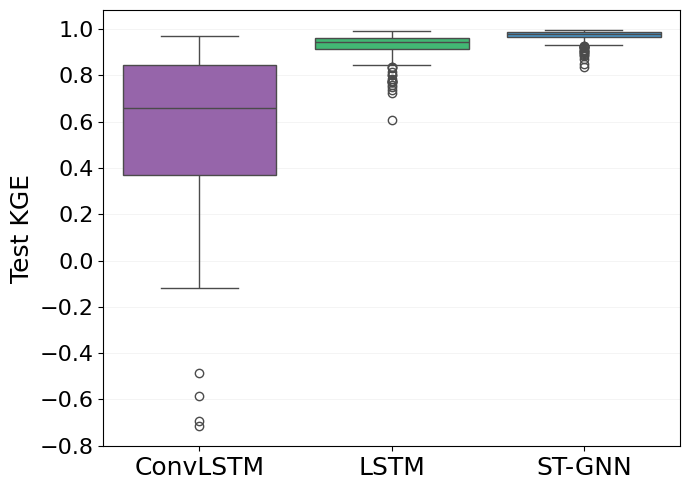

In [31]:
# Box plot: KGE by model
model_order = ['ConvLSTM', 'LSTM', 'ST-GNN']
colors = {'ST-GNN': '#2ecc71', 'ConvLSTM': '#3498db', 'LSTM': '#9b59b6'}
palette = [colors[m] for m in model_order]

plt.figure(figsize=(7, 5))
ax = sns.boxplot(data=kge_combined, x='Model', y='Test KGE', hue='Model', order=model_order, palette=palette, legend=False)
plt.title('')
plt.ylabel('Test KGE', fontsize=18)
plt.xlabel('')
plt.xticks(fontsize=18)
plt.yticks(fontsize=16)
plt.grid(True, which='major', axis='y', color='gray', linestyle='-', linewidth=0.4, alpha=0.15)

kge_min = kge_combined['Test KGE'].min()
kge_max = kge_combined['Test KGE'].max()
ytick_start = -0.8
ytick_stop = 1
yticks = np.arange(ytick_start, ytick_stop + 0.2, 0.2)
plt.yticks(yticks)

plt.tight_layout()
plt.show()